# HW10-11: Computer Vision in PyTorch

Часть A: классификация (CIFAR100).

Часть B: сегментация (OxfordIIITPet).

## 0. Импорты, seed, устройство

In [1]:
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import matplotlib.pyplot as plt

# --- Repro ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

DATA_DIR = Path('data')
ARTIFACTS_DIR = Path('artifacts')
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


device: cpu


## 1. Часть A: CIFAR100 — данные, трансформы, DataLoader

In [2]:
# --- Dataset choice ---
DATASET_NAME_A = 'CIFAR100'
NUM_CLASSES = 100

# CIFAR100 stats (train)
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

base_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

aug_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

# ResNet18 classification track uses pretrained ImageNet weights.
resnet_weights = ResNet18_Weights.DEFAULT
resnet_tf = resnet_weights.transforms()
print('ResNet18 pretrained weights:', resnet_weights)

# Base datasets (no split yet)
train_full_base = torchvision.datasets.CIFAR100(
    root=DATA_DIR, train=True, download=True, transform=base_tf
)
train_full_aug = torchvision.datasets.CIFAR100(
    root=DATA_DIR, train=True, download=False, transform=aug_tf
)
train_full_resnet = torchvision.datasets.CIFAR100(
    root=DATA_DIR, train=True, download=False, transform=resnet_tf
)

# Fixed split indices
val_fraction = 0.2
n_train = len(train_full_base)
indices = np.arange(n_train)
rs = np.random.RandomState(SEED)
rs.shuffle(indices)
val_size = int(n_train * val_fraction)
val_idx = indices[:val_size]
train_idx = indices[val_size:]

train_base = Subset(train_full_base, train_idx)
val_base = Subset(train_full_base, val_idx)

train_aug = Subset(train_full_aug, train_idx)
val_aug = Subset(train_full_aug, val_idx)

train_resnet = Subset(train_full_resnet, train_idx)
val_resnet = Subset(train_full_resnet, val_idx)

test_base = torchvision.datasets.CIFAR100(
    root=DATA_DIR, train=False, download=True, transform=base_tf
)
test_resnet = torchvision.datasets.CIFAR100(
    root=DATA_DIR, train=False, download=False, transform=resnet_tf
)

# Loaders
BATCH_SIZE = 128
NUM_WORKERS = 2

train_loader_base = DataLoader(train_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_base = DataLoader(val_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_loader_aug = DataLoader(train_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_aug = DataLoader(val_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train_loader_resnet = DataLoader(train_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader_resnet = DataLoader(val_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

test_loader_base = DataLoader(test_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader_resnet = DataLoader(test_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Sanity check
xb, yb = next(iter(train_loader_base))
print('x.shape:', xb.shape, 'y.shape:', yb.shape)


ResNet18 pretrained weights: ResNet18_Weights.IMAGENET1K_V1


/usr/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
/usr/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x.shape: torch.Size([128, 3, 32, 32]) y.shape: torch.Size([128])


### Визуализация аугментаций

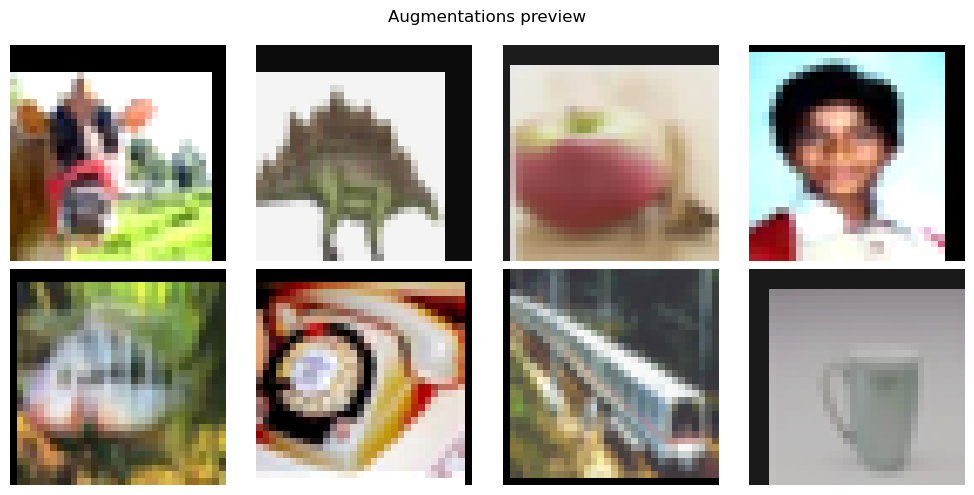

In [3]:
def denorm_cifar(x):
    mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)

# preview augmentations
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

preview_ds = torchvision.datasets.CIFAR100(root=DATA_DIR, train=True, download=False, transform=aug_tf)
for i in range(8):
    img, _ = preview_ds[i]
    img = denorm_cifar(img)
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].axis('off')

fig.suptitle('Augmentations preview')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'augmentations_preview.png', dpi=150)
plt.show()


## 2. Часть A: модели, обучение, оценка

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total


### Эксперименты C1–C4

In [5]:
@dataclass
class RunResult:
    experiment_id: str
    task: str
    dataset: str
    seed: int
    model_summary: str
    optimizer: str
    lr: float
    epochs_trained: int
    best_val_accuracy: float
    test_accuracy: float
    precision: float
    recall: float
    mean_iou: float
    notes: str


def csv_value(value):
    if isinstance(value, float) and math.isnan(value):
        return ''
    return value


def run_classification_experiment(experiment_id, model, train_loader, val_loader, epochs, lr, optimizer_name='adam'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    if optimizer_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"{experiment_id} | epoch {epoch:02d} | train acc {tr_acc:.4f} | val acc {va_acc:.4f}")

    return history, best_val_acc, best_state


EPOCHS_CNN = 5
EPOCHS_RESNET = 5

runs = []

# C1: simple CNN, no aug
model_c1 = SimpleCNN(NUM_CLASSES)

hist_c1, best_val_c1, state_c1 = run_classification_experiment(
    'C1', model_c1, train_loader_base, val_loader_base, EPOCHS_CNN, lr=1e-3, optimizer_name='adam'
)

runs.append(RunResult('C1', 'classification', DATASET_NAME_A, SEED, 'SimpleCNN', 'Adam', 1e-3, EPOCHS_CNN, best_val_c1, float('nan'), float('nan'), float('nan'), float('nan'), 'base'))

# C2: simple CNN, with aug
model_c2 = SimpleCNN(NUM_CLASSES)

hist_c2, best_val_c2, state_c2 = run_classification_experiment(
    'C2', model_c2, train_loader_aug, val_loader_aug, EPOCHS_CNN, lr=1e-3, optimizer_name='adam'
)

runs.append(RunResult('C2', 'classification', DATASET_NAME_A, SEED, 'SimpleCNN', 'Adam', 1e-3, EPOCHS_CNN, best_val_c2, float('nan'), float('nan'), float('nan'), float('nan'), 'aug'))

# C3: ResNet18 head-only
model_c3 = resnet18(weights=resnet_weights)
for p in model_c3.parameters():
    p.requires_grad = False
model_c3.fc = nn.Linear(model_c3.fc.in_features, NUM_CLASSES)

hist_c3, best_val_c3, state_c3 = run_classification_experiment(
    'C3', model_c3, train_loader_resnet, val_loader_resnet, EPOCHS_RESNET, lr=1e-3, optimizer_name='sgd'
)

runs.append(RunResult('C3', 'classification', DATASET_NAME_A, SEED, 'ResNet18(head-only)', 'SGD', 1e-3, EPOCHS_RESNET, best_val_c3, float('nan'), float('nan'), float('nan'), float('nan'), 'head-only'))

# C4: ResNet18 partial fine-tune (layer4 + fc)
model_c4 = resnet18(weights=resnet_weights)
for p in model_c4.parameters():
    p.requires_grad = False
for p in model_c4.layer4.parameters():
    p.requires_grad = True
model_c4.fc = nn.Linear(model_c4.fc.in_features, NUM_CLASSES)

hist_c4, best_val_c4, state_c4 = run_classification_experiment(
    'C4', model_c4, train_loader_resnet, val_loader_resnet, EPOCHS_RESNET, lr=1e-4, optimizer_name='sgd'
)

runs.append(RunResult('C4', 'classification', DATASET_NAME_A, SEED, 'ResNet18(layer4+fc)', 'SGD', 1e-4, EPOCHS_RESNET, best_val_c4, float('nan'), float('nan'), float('nan'), float('nan'), 'partial fine-tune'))


C1 | epoch 01 | train acc 0.0958 | val acc 0.1903
C1 | epoch 02 | train acc 0.2142 | val acc 0.2726
C1 | epoch 03 | train acc 0.2773 | val acc 0.3191
C1 | epoch 04 | train acc 0.3250 | val acc 0.3449
C1 | epoch 05 | train acc 0.3647 | val acc 0.3634
C2 | epoch 01 | train acc 0.0637 | val acc 0.1250
C2 | epoch 02 | train acc 0.1393 | val acc 0.1894
C2 | epoch 03 | train acc 0.1830 | val acc 0.2255
C2 | epoch 04 | train acc 0.2145 | val acc 0.2566
C2 | epoch 05 | train acc 0.2366 | val acc 0.2730
C3 | epoch 01 | train acc 0.1121 | val acc 0.2334
C3 | epoch 02 | train acc 0.3049 | val acc 0.3527
C3 | epoch 03 | train acc 0.3948 | val acc 0.4094
C3 | epoch 04 | train acc 0.4395 | val acc 0.4386
C3 | epoch 05 | train acc 0.4658 | val acc 0.4572
C4 | epoch 01 | train acc 0.0198 | val acc 0.0346
C4 | epoch 02 | train acc 0.0583 | val acc 0.0883
C4 | epoch 03 | train acc 0.1173 | val acc 0.1460
C4 | epoch 04 | train acc 0.1764 | val acc 0.1977
C4 | epoch 05 | train acc 0.2268 | val acc 0.2439


### Выбор лучшей модели и оценка на test (только один раз)

In [6]:
# pick best by val acc
best_id = max(runs, key=lambda r: r.best_val_accuracy).experiment_id
print('best experiment:', best_id)

best_state = {'C1': state_c1, 'C2': state_c2, 'C3': state_c3, 'C4': state_c4}[best_id]

# Build matching model + loader
if best_id in ('C1', 'C2'):
    best_model = SimpleCNN(NUM_CLASSES)
    test_loader = test_loader_base
else:
    best_model = resnet18(weights=resnet_weights)
    best_model.fc = nn.Linear(best_model.fc.in_features, NUM_CLASSES)
    test_loader = test_loader_resnet

best_model.load_state_dict(best_state)

criterion = nn.CrossEntropyLoss()
_, test_acc = evaluate(best_model.to(device), test_loader, criterion, device)

# update run record
for r in runs:
    if r.experiment_id == best_id:
        r.test_accuracy = test_acc
        break

print('test_accuracy:', test_acc)

# save best model + config
best_model_path = ARTIFACTS_DIR / 'best_classifier.pt'
config_path = ARTIFACTS_DIR / 'best_classifier_config.json'

torch.save(best_model.cpu().state_dict(), best_model_path)

best_config = {
    'dataset': DATASET_NAME_A,
    'best_experiment': best_id,
    'seed': SEED,
    'num_classes': NUM_CLASSES,
    'model_name': 'SimpleCNN' if best_id in ('C1', 'C2') else 'ResNet18',
    'architecture': 'custom SimpleCNN classifier' if best_id in ('C1', 'C2') else 'torchvision ResNet18 with replaced final fc layer',
    'pretrained_weights': 'not used' if best_id in ('C1', 'C2') else str(resnet_weights),
    'fine_tuning_scope': 'full model trained from scratch' if best_id == 'C1' else ('full model trained with augmentation' if best_id == 'C2' else ('head-only fine-tuning' if best_id == 'C3' else 'layer4 + fc fine-tuning')),
    'transforms': 'base' if best_id in ('C1', 'C2') else 'resnet18_weights.transforms()',
    'optimizer': 'Adam' if best_id in ('C1', 'C2') else 'SGD',
    'epochs': EPOCHS_CNN if best_id in ('C1', 'C2') else EPOCHS_RESNET,
}
config_path.write_text(json.dumps(best_config, indent=2))


best experiment: C3
test_accuracy: 0.4642


381

### Графики и таблица экспериментов части A

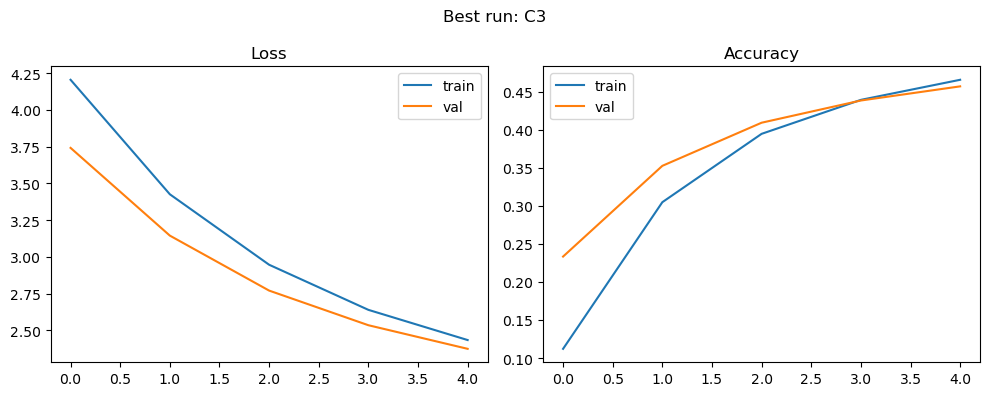

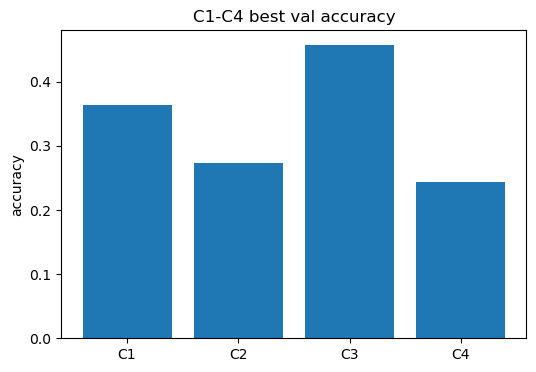

In [7]:
# Curves for best run
hist_map = {'C1': hist_c1, 'C2': hist_c2, 'C3': hist_c3, 'C4': hist_c4}

best_hist = hist_map[best_id]
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(best_hist['train_loss'], label='train')
ax[0].plot(best_hist['val_loss'], label='val')
ax[0].set_title('Loss')
ax[0].legend()

ax[1].plot(best_hist['train_acc'], label='train')
ax[1].plot(best_hist['val_acc'], label='val')
ax[1].set_title('Accuracy')
ax[1].legend()

fig.suptitle(f'Best run: {best_id}')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'classification_curves_best.png', dpi=150)
plt.show()

# Compare C1-C4 by val acc
labels = [r.experiment_id for r in runs]
vals = [r.best_val_accuracy for r in runs]
plt.figure(figsize=(6, 4))
plt.bar(labels, vals)
plt.title('C1-C4 best val accuracy')
plt.ylabel('accuracy')
plt.savefig(FIGURES_DIR / 'classification_compare.png', dpi=150)
plt.show()

# Save runs.csv (part A; part B will append later)
import csv
runs_csv = ARTIFACTS_DIR / 'runs.csv'

with runs_csv.open('w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'experiment_id', 'task', 'dataset', 'seed', 'model_summary', 'optimizer', 'lr',
        'epochs_trained', 'best_val_accuracy', 'test_accuracy', 'precision', 'recall', 'mean_iou', 'notes'
    ])
    for r in runs:
        writer.writerow([
            r.experiment_id, r.task, r.dataset, r.seed, r.model_summary, r.optimizer, r.lr,
            r.epochs_trained, csv_value(r.best_val_accuracy), csv_value(r.test_accuracy), csv_value(r.precision), csv_value(r.recall), csv_value(r.mean_iou), r.notes
        ])


## 3. Часть B: OxfordIIITPet — сегментация

In [8]:
DATASET_NAME_B = 'OxfordIIITPet'
SEG_FOREGROUND_CLASS = 1
SEG_FOREGROUND_LABEL = 'pet'
print(f'Segmentation foreground class: {SEG_FOREGROUND_LABEL} (trimap={SEG_FOREGROUND_CLASS})')

# Paired transforms (image + mask)
class PetSegDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds, image_tf, mask_tf):
        self.base_ds = base_ds
        self.image_tf = image_tf
        self.mask_tf = mask_tf
    def __len__(self):
        return len(self.base_ds)
    def __getitem__(self, idx):
        img, mask = self.base_ds[idx]
        img = self.image_tf(img)
        mask = self.mask_tf(mask)
        return img, mask

seg_weights = DeepLabV3_ResNet50_Weights.DEFAULT

# Force fixed spatial size for batching
seg_size = 520

seg_tf_img = transforms.Compose([
    transforms.Resize((seg_size, seg_size), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=seg_weights.meta.get('mean', (0.485, 0.456, 0.406)),
                         std=seg_weights.meta.get('std', (0.229, 0.224, 0.225))),
])

mask_tf = transforms.Compose([
    transforms.Resize((seg_size, seg_size), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
])

pet_train = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split='trainval', target_types='segmentation', download=True
)
pet_test = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split='test', target_types='segmentation', download=True
)

pet_train_ds = PetSegDataset(pet_train, seg_tf_img, mask_tf)
pet_test_ds = PetSegDataset(pet_test, seg_tf_img, mask_tf)

SEG_BATCH = 4
SEG_NUM_WORKERS = 0
seg_loader = DataLoader(pet_test_ds, batch_size=SEG_BATCH, shuffle=False, num_workers=SEG_NUM_WORKERS)

# sanity check
x_seg, y_seg = next(iter(seg_loader))
print('seg x:', x_seg.shape, 'seg y:', y_seg.shape)


Segmentation foreground class: pet (trimap=1)


100.0%
100.0%


seg x: torch.Size([4, 3, 520, 520]) seg y: torch.Size([4, 1, 520, 520])


### Инференс и метрики (V1/V2)

In [9]:
def to_binary_mask(mask_tensor):
    mask_tensor = mask_tensor.long()
    # OxfordIIITPet trimap foreground class: pet (class id 1).
    # We evaluate binary segmentation where foreground is the pet mask.
    return (mask_tensor == SEG_FOREGROUND_CLASS).squeeze(1)


def binary_metrics(pred, target):
    pred = pred.bool()
    target = target.bool()
    tp = (pred & target).sum().item()
    fp = (pred & ~target).sum().item()
    fn = (~pred & target).sum().item()
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    return precision, recall, iou


def run_segmentation_eval(score_threshold=0.5, max_samples=50):
    model = deeplabv3_resnet50(weights=seg_weights).to(device)
    model.eval()

    precisions, recalls, ious = [], [], []
    seen = 0
    with torch.no_grad():
        for x, y in seg_loader:
            x = x.to(device)
            y = y.to(device)
            out = model(x)['out']
            probs = torch.softmax(out, dim=1)
            bg = probs[:, 0]  # background prob
            pred = (1.0 - bg) > score_threshold

            target = to_binary_mask(y)
            for i in range(x.size(0)):
                p, r, iou = binary_metrics(pred[i], target[i])
                precisions.append(p)
                recalls.append(r)
                ious.append(iou)
                seen += 1
                if seen >= max_samples:
                    return float(np.mean(precisions)), float(np.mean(recalls)), float(np.mean(ious))

    return float(np.mean(precisions)), float(np.mean(recalls)), float(np.mean(ious))

# V1
v1_precision, v1_recall, v1_iou = run_segmentation_eval(score_threshold=0.5, max_samples=50)
print('V1:', v1_precision, v1_recall, v1_iou)

# V2 (alt postprocessing: higher threshold)
v2_precision, v2_recall, v2_iou = run_segmentation_eval(score_threshold=0.7, max_samples=50)
print('V2:', v2_precision, v2_recall, v2_iou)


V1: 0.6574974964436787 0.9835667226282381 0.6491098009614226
V2: 0.7443426616834171 0.963763471172599 0.7180194124169301


### Визуализации сегментации

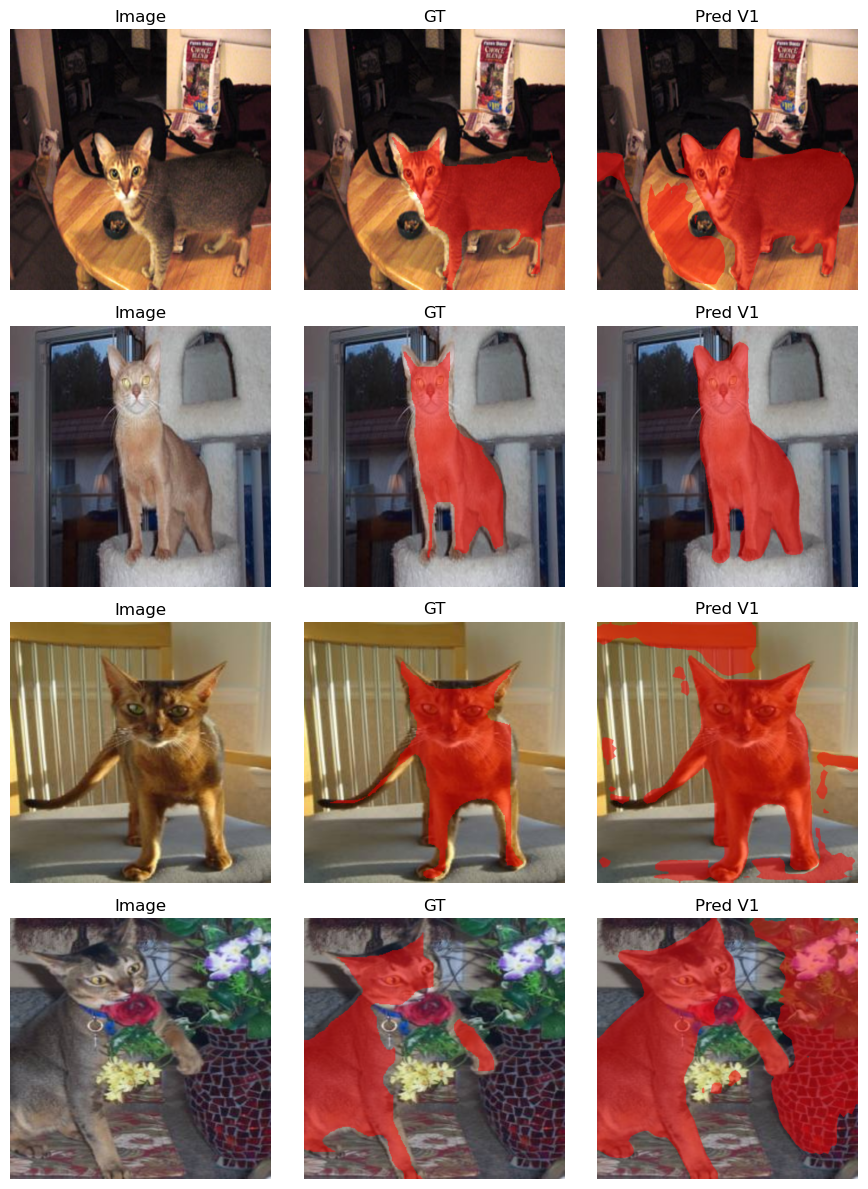

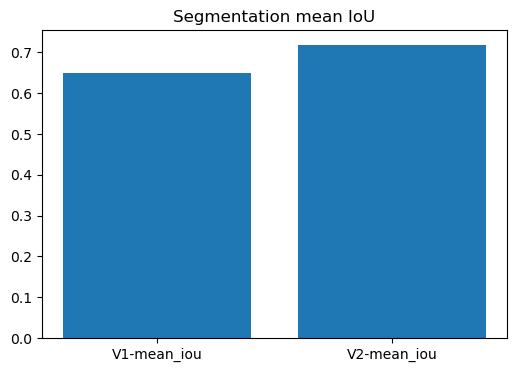

In [10]:
seg_mean = torch.tensor(seg_weights.meta.get('mean', (0.485, 0.456, 0.406))).view(3, 1, 1)
seg_std = torch.tensor(seg_weights.meta.get('std', (0.229, 0.224, 0.225))).view(3, 1, 1)

def denorm_seg(x):
    return (x * seg_std + seg_mean).clamp(0, 1)


def overlay_mask(img, mask, alpha=0.5):
    # img: tensor CxHxW in [0,1]
    img = img.permute(1, 2, 0).cpu().numpy()
    mask = mask.cpu().numpy()
    overlay = img.copy()
    overlay[mask] = [1.0, 0.0, 0.0]
    return (1 - alpha) * img + alpha * overlay

model_seg = deeplabv3_resnet50(weights=seg_weights).to(device)
model_seg.eval()

examples = []
with torch.no_grad():
    x, y = next(iter(seg_loader))
    out = model_seg(x.to(device))['out']
    probs = torch.softmax(out, dim=1)
    bg = probs[:, 0]
    pred_v1 = (1.0 - bg) > 0.5

    target = to_binary_mask(y)

    for i in range(min(4, x.size(0))):
        examples.append((denorm_seg(x[i]), target[i], pred_v1[i]))

fig, axes = plt.subplots(len(examples), 3, figsize=(9, 3 * len(examples)))
for r, (img, gt, pred) in enumerate(examples):
    axes[r, 0].imshow(img.permute(1, 2, 0))
    axes[r, 0].set_title('Image')
    axes[r, 0].axis('off')

    axes[r, 1].imshow(overlay_mask(img, gt))
    axes[r, 1].set_title('GT')
    axes[r, 1].axis('off')

    axes[r, 2].imshow(overlay_mask(img, pred))
    axes[r, 2].set_title('Pred V1')
    axes[r, 2].axis('off')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'segmentation_examples.png', dpi=150)
plt.show()

# Metrics bar plot
plt.figure(figsize=(6, 4))
plt.bar(['V1-mean_iou', 'V2-mean_iou'], [v1_iou, v2_iou])
plt.title('Segmentation mean IoU')
plt.savefig(FIGURES_DIR / 'segmentation_metrics.png', dpi=150)
plt.show()


### Запись результатов части B в runs.csv

In [11]:
import csv

runs_csv = ARTIFACTS_DIR / 'runs.csv'

rows = []
with runs_csv.open('r', newline='') as f:
    reader = csv.reader(f)
    rows = list(reader)

rows.append(['V1', 'segmentation', DATASET_NAME_B, SEED, 'DeepLabV3_ResNet50', 'N/A', 'N/A', 0, '', '', v1_precision, v1_recall, v1_iou, 'threshold=0.5; foreground=pet(class=1)'])
rows.append(['V2', 'segmentation', DATASET_NAME_B, SEED, 'DeepLabV3_ResNet50', 'N/A', 'N/A', 0, '', '', v2_precision, v2_recall, v2_iou, 'threshold=0.7; foreground=pet(class=1)'])

with runs_csv.open('w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(rows)
